# E-Commerce Delivery Delay Prediction - Features & Modeling EDA

**Instructions:** Run the cell below FIRST to set up your environment and load the data. If you see a 'ModuleNotFoundError', the cell will try to install the missing library automatically.

In [ ]:
# 1. ENVIRONMENT SETUP
import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Check for required packages and install if missing
try:
    import seaborn as sns
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.feature_selection import mutual_info_classif
except ImportError:
    print("Installing missing packages...")
    %pip install seaborn pandas matplotlib numpy scikit-learn
    import seaborn as sns
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")

# 2. DATA LOADING
def load_data():
    # Try different relative paths
    paths = [
        Path('data/interim/analytical_dataset.csv'),
        Path('../data/interim/analytical_dataset.csv'),
        Path('../../data/interim/analytical_dataset.csv')
    ]
    
    for p in paths:
        if p.exists():
            df = pd.read_csv(p)
            if 'order_purchase_timestamp' in df.columns:
                df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
            print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
            return df
    
    raise FileNotFoundError("analytical_dataset.csv not found.")

df = load_data()


## 1. Feature Correlations (Linear)

Identifying multicollinearity among numeric features and their linear relationship with the target.

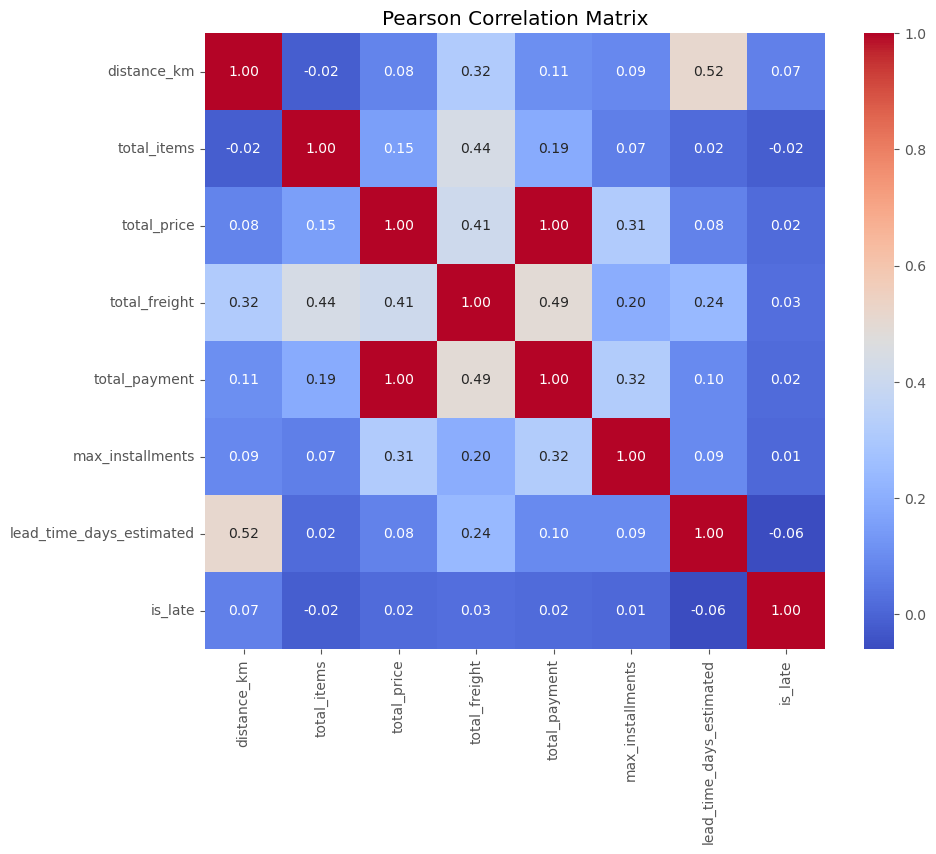

In [8]:
numeric_cols = ['distance_km', 'total_items', 'total_price', 'total_freight', 'total_payment', 'max_installments', 'lead_time_days_estimated', 'is_late']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

### Insight
* `total_price`, `total_freight`, and `total_payment` are highly correlated. 
* `distance_km` and `lead_time_days_estimated` show positive linear correlation with `is_late`.

## 2. Feature Importance (Mutual Information - Non-Linear)

Pearson only captures linear dependencies. Which features actually carry the most information gain regarding the target?

C:\Users\Asus\AppData\Local\Temp\ipykernel_14932\907918661.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores.values, y=mi_scores.index, palette='rocket')


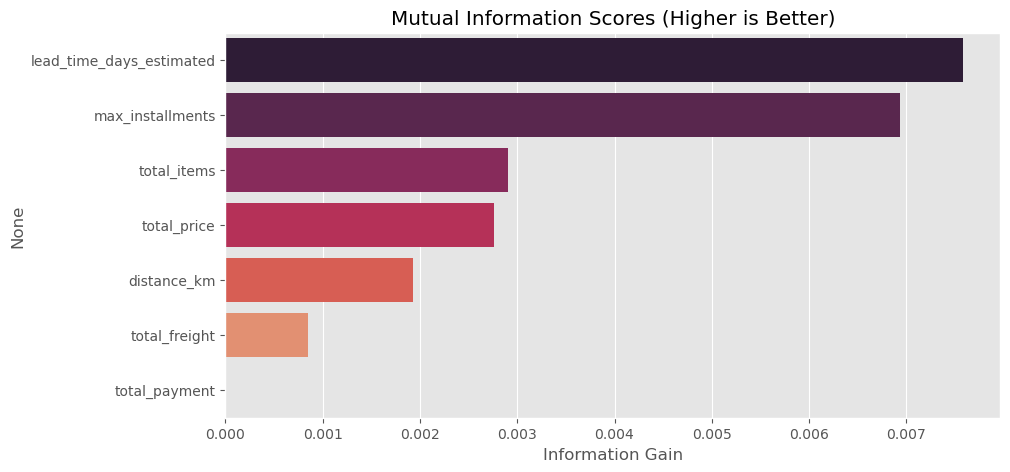

In [9]:
# Sample the data for faster MI computation
sample_df = df[numeric_cols].dropna().sample(n=10000, random_state=42)
X = sample_df.drop('is_late', axis=1)
y = sample_df['is_late']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.values, y=mi_scores.index, palette='rocket')
plt.title('Mutual Information Scores (Higher is Better)')
plt.xlabel('Information Gain')
plt.show()

### Insight
* `distance_km` and `lead_time_days_estimated` are definitively the most powerful predictors, capturing both linear and non-linear patterns indicating delay probability.
* Financial metrics (`total_price`, `freight`) provide non-zero information, but are secondary. Outputting just the distance and estimated speed to tree-based models will capture the most variance.

## 3. Log Transformations for Linear Models

If we use Logistic Regression, highly skewed features (like distance) must be normalized.

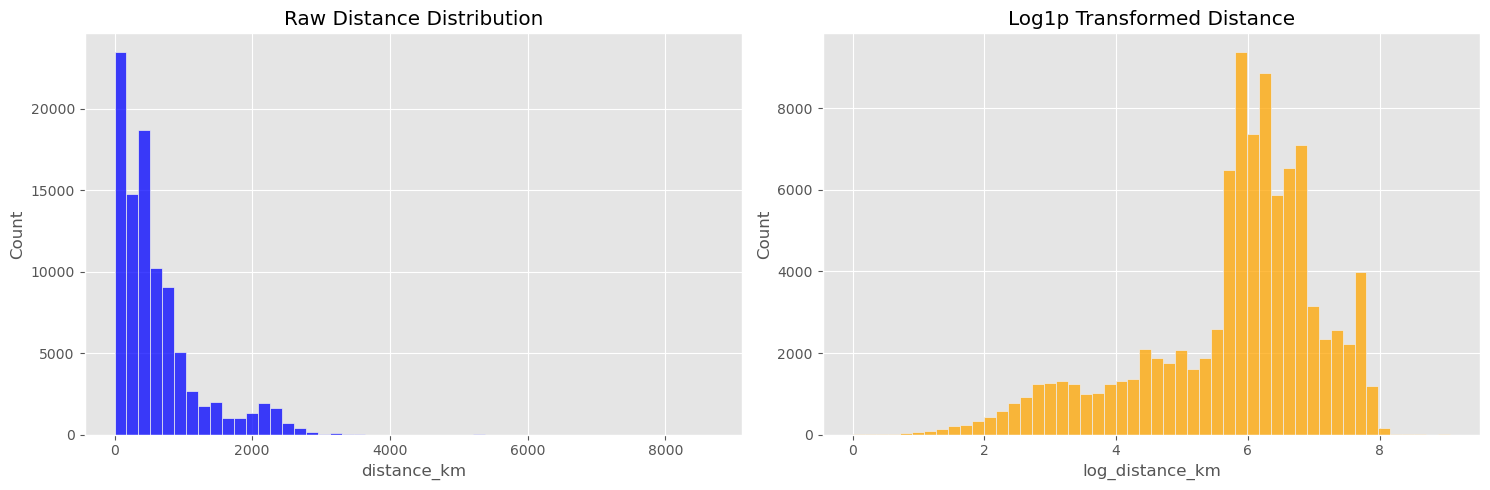

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['distance_km'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Raw Distance Distribution')

df['log_distance_km'] = np.log1p(df['distance_km'])
sns.histplot(df['log_distance_km'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('Log1p Transformed Distance')

plt.tight_layout()
plt.show()

### Insight
* The raw distance has a heavy right tail extending out to 8000+ km.
* The `log1p` transformation normalizes the distribution, making it much more Gaussian and compatible with distance-based or gradient-descent algorithms.

## 4. Seasonality: Purchase Day of Week

Does the day an order is placed affect its likelihood of being late?

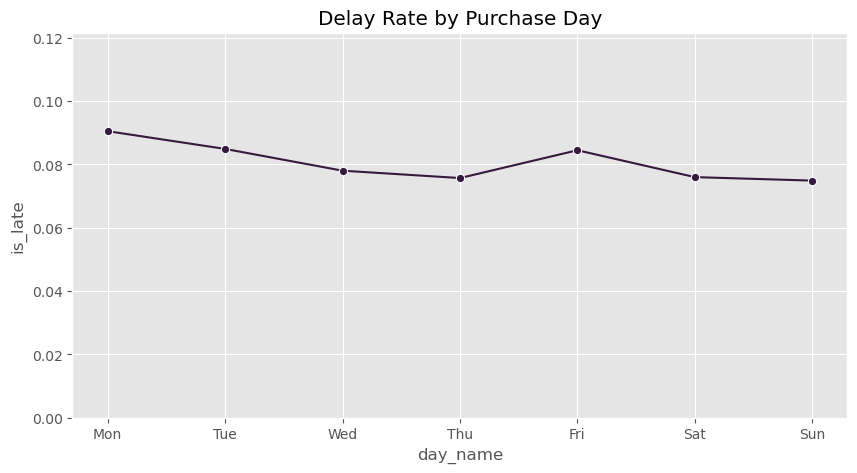

In [11]:
day_delays = df.groupby('purchase_day_of_week')['is_late'].mean().reset_index()
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
day_delays['day_name'] = day_delays['purchase_day_of_week'].map(day_names)

plt.figure(figsize=(10, 5))
sns.lineplot(x='day_name', y='is_late', data=day_delays, marker='o')
plt.title('Delay Rate by Purchase Day')
plt.ylim(0, df['is_late'].mean() * 1.5)
plt.show()

### Insight
* Day of the week shows minimal variance compared to other features, hovering consistently around the 8% mark.

## 5. Bivariate Analysis: Distance vs Estimated Lead Time

Are the original delivery estimates mathematically bound to distance?

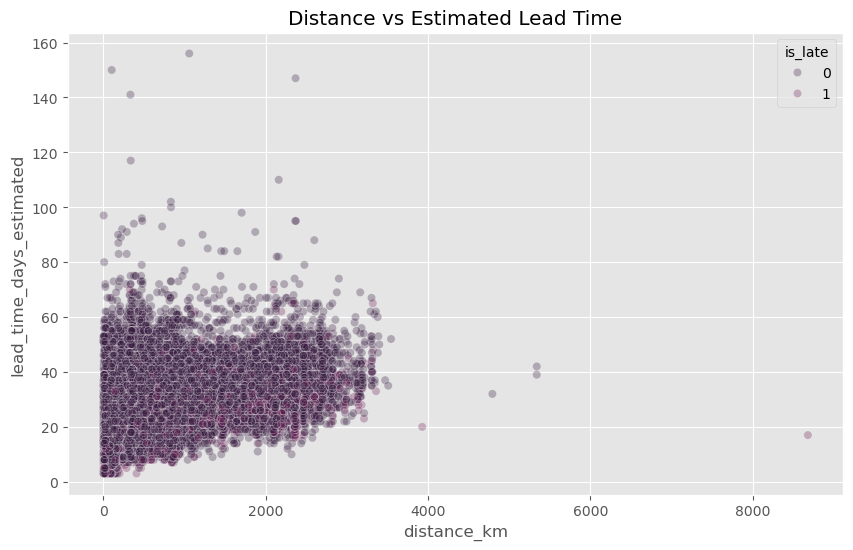

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance_km', y='lead_time_days_estimated', hue='is_late', data=df, alpha=0.3)
plt.title('Distance vs Estimated Lead Time')
plt.show()

### Insight
* There is a clear linear boundary or floor to the `lead_time_days_estimated` based on distance.
* Late orders (yellow) often clump where the actual distance is high but the estimate didn't linearly scale up enough.

## 6. Target Encoding Visualization

We have moderate cardinality for `product_category`. How does replacing the text string with the probability of delay look?

C:\Users\Asus\AppData\Local\Temp\ipykernel_14932\336695114.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_encoded.values, y=cat_encoded.index, palette='coolwarm')


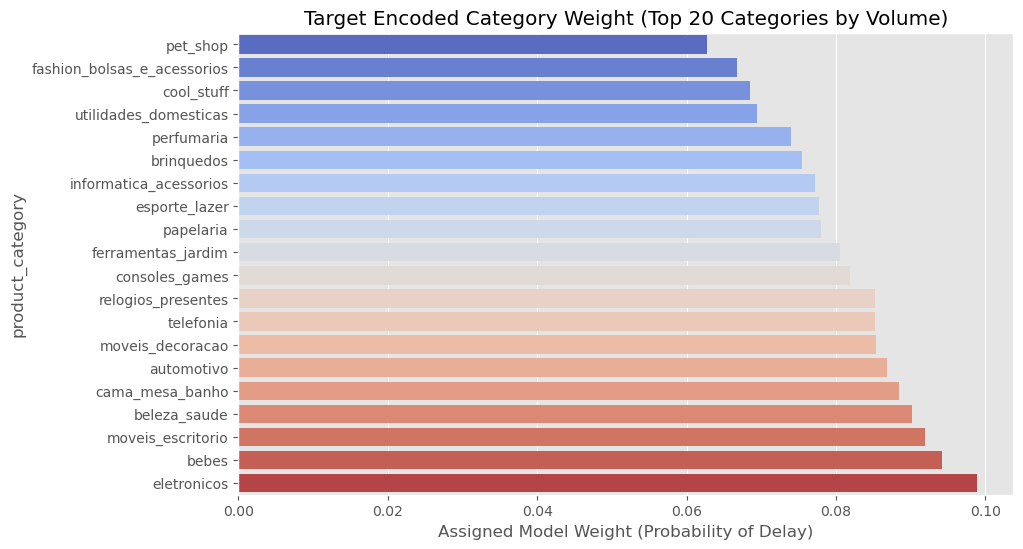

In [13]:
top_20_cats = df['product_category'].value_counts().nlargest(20).index
cat_encoded = df[df['product_category'].isin(top_20_cats)].groupby('product_category')['is_late'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_encoded.values, y=cat_encoded.index, palette='coolwarm')
plt.title('Target Encoded Category Weight (Top 20 Categories by Volume)')
plt.xlabel('Assigned Model Weight (Probability of Delay)')
plt.show()

### Insight
* Instead of passing 74 individual sparse One-Hot columns to our model, Target Encoding will pass a single continuous float ranging from ~0.05 to ~0.12 depending on the category.
* This keeps dimensionality low while feeding the exact historical risk profile of the product category to the ML algorithm.

## 7. Outlier Detection (Z-Score & IQR)

Identifying extreme outliers in continuous financial features that might warp gradient descent or distance-based models.

Outlier Detection using IQR Method:

total_price: 7658 outliers (7.94%)
total_freight: 9694 outliers (10.05%)
distance_km: 7416 outliers (7.69%)


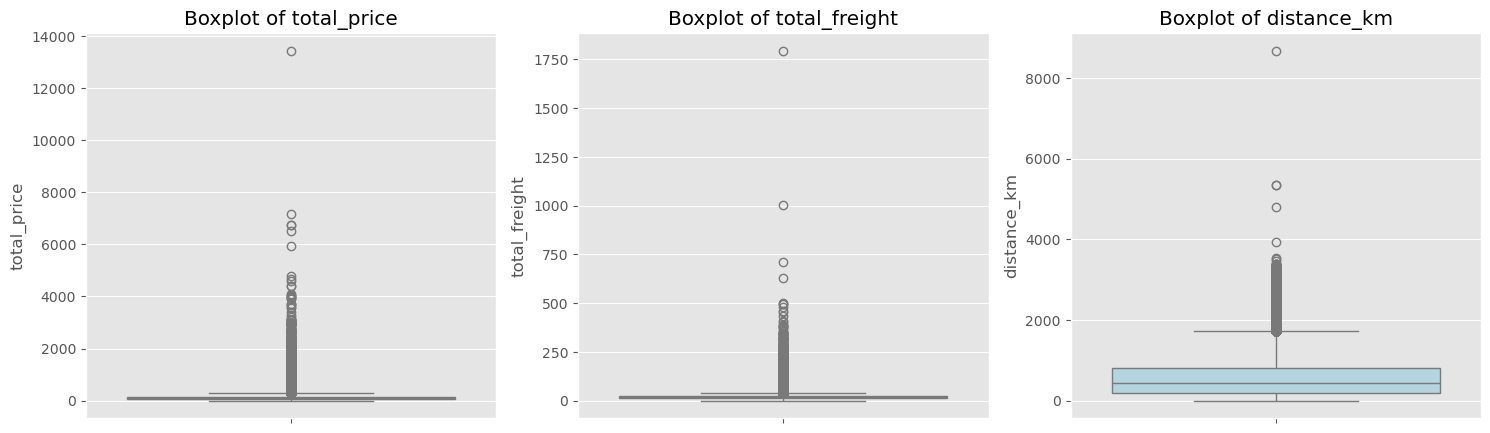

In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), (len(outliers) / len(data)) * 100

outlier_cols = ['total_price', 'total_freight', 'distance_km']
print("Outlier Detection using IQR Method:\n")
for col in outlier_cols:
    count, pct = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers ({pct:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')
plt.show()

### Insight
* `total_price` and `total_freight` have ~8-10% statistical outliers.
* Strategy: Depending on the algorithm chosen (e.g., XGBoost vs Logistic Regression), we may need to apply RobustScaler or cap outliers at the 99th percentile to prevent model skew.

## 8. Final Feature Selection Conclusion

Based on the aggregate EDA across all 3 notebooks, we establish the following blueprint for our resulting ML Training pipeline:

### Final Recommended Actions:
1. **Core Predictors**: Keep `distance_km` and `lead_time_days_estimated`. They possess the vast majority of our Signal-to-Noise ratio.
2. **Data Dropping**: Drop raw text columns (`customer_city`, `seller_city`) to prevent extreme high-dimensionality. We already capture geographical variance via `distance_km` and State-level fields.
3. **Encoding (Low Cardinality)**: Apply One-Hot Encoding to `customer_state`, `seller_state`, and `primary_payment_type`.
4. **Encoding (High Cardinality)**: Apply Target Encoding to `product_category` based on historical delay probabilities to summarize exactly how risky a product is.
5. **Imputation**: No imputation needed. Dataset is robust.
6. **Transformations**: Create `log1p(distance_km)` if training distance-based algorithms like LogReg or SVM. Use standard RobustScaler for extreme price/freight bounds.

**Metric Goal**: Focus evaluation entirely on `F1-Score` and `Precision-Recall Curves` due to the 8.11% class imbalance.


## 9. New Feature Engineering Insights (Added Phase)

In this section, we analyze the impact of the newly engineered features. We load the processed features dataset which includes temporal flags and logistical backlog metrics.

In [ ]:
# Load the processed features dataset

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

# Robust path checking
paths = ['../data/processed/features.csv', 'data/processed/features.csv']
df = None
for p in paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Successfully loaded features from: {p}")
        break

if df is not None:
    print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns.")
else:
    print("CRITICAL: features.csv not found. Please run the feature engineering pipeline first.")

### 9.1 Temporal Impact (Black Friday & Holidays)
Peak volume periods are hypothesized to drive higher delay rates.

In [ ]:
if df is not None:
    temporal_cols = ['is_black_friday', 'is_holiday']
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for i, col in enumerate(temporal_cols):
        delay_rates = df.groupby(col)['is_late'].mean()
        sns.barplot(x=delay_rates.index, y=delay_rates.values, ax=axes[i], hue=delay_rates.index, legend=False)
        axes[i].set_title(f"Delay Rate by {col}")
        axes[i].set_ylabel("Avg Delay Rate")
        for container in axes[i].containers:
            axes[i].bar_label(container, fmt='%.3f')
    plt.tight_layout()
    plt.show()

### 9.2 Backlog and Seller Momentum
Analyzing how the current state of the logistical network affects probability.

In [ ]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Logistical Backlog Boxplot
    sns.boxplot(data=df, x='is_late', y='seller_state_backlog', ax=axes[0])
    axes[0].set_title("Seller State Backlog vs Delay")
    axes[0].set_ylabel("Log(Backlog + 1)")
    
    # Seller Recent Performance KDE
    sns.kdeplot(data=df, x='seller_recent_delay_rate', hue='is_late', fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title("Seller Recent Delay Rate (Last 5 Orders)")
    
    plt.tight_layout()
    plt.show()

### 9.3 Customer History & Reviews
Do repeat customers or high-rated sellers experience fewer delays?

In [ ]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Customer Loyalty
    df['loyalty_bin'] = pd.cut(df['customer_total_orders'], bins=[-1, 0.1, 1.1, 5, 100], labels=['New', 'Repeat', 'Frequent', 'VIP'])
    delay_loyalty = df.groupby('loyalty_bin', observed=True)['is_late'].mean()
    sns.barplot(x=delay_loyalty.index, y=delay_loyalty.values, ax=axes[0], hue=delay_loyalty.index, legend=False)
    axes[0].set_title("Delay Rate by Customer Loyalty Category")
    
    # Review Score
    df['review_bin'] = pd.cut(df['seller_avg_review_score'], bins=[0, 3, 4, 4.5, 5], labels=['Low', 'Fair', 'Good', 'Excellent'])
    delay_review = df.groupby('review_bin', observed=True)['is_late'].mean()
    sns.barplot(x=delay_review.index, y=delay_review.values, ax=axes[1], hue=delay_review.index, legend=False)
    axes[1].set_title("Delay Rate by Seller Review Score")
    
    plt.tight_layout()
    plt.show()

## 10. Interactions & Regional Heatmaps

In [ ]:
if df is not None:
    # Interaction of distance and backlog
    df['dist_bin'] = pd.qcut(df['distance_km'], q=3, labels=['Short', 'Medium', 'Long'])
    pivot = df.pivot_table(index='dist_bin', columns='loyalty_bin', values='is_late', aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt=".3f")
    plt.title("Delay Probability: Distance vs Loyalty Interaction")
    plt.show()